In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import os

from core.Res18Unet import ResNet18Segmentation
from LoadData import get_loaders
from utils.myDisplay import Animator
import matplotlib.pyplot as plt
import numpy as np

In [4]:
class DiceLoss(nn.Module):
    """Dice Loss - 更高效的实现"""
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        """
        pred: [batch, num_classes, height, width]
        target: [batch, height, width]
        """
        # 对预测值应用 softmax
        pred = torch.softmax(pred, dim=1)
        
        # 创建 one-hot target
        target = torch.nn.functional.one_hot(target, num_classes=pred.shape[1])  # [B, H, W, C]
        target = target.permute(0, 3, 1, 2).float()  # [B, C, H, W]
        
        # 计算 Dice
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        
        return (1 - dice).mean()

In [ ]:

# 配置参数
data_dir = './data/raw/IR'
batch_size = 4
epochs = 15
lr = 1e-4
val_split = 0.2
device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
print(f"Using device: {device}")
    
# 获取数据加载器
train_loader, val_loader = get_loaders(
    data_dir=data_dir,
    batch_size=batch_size,
    val_split=val_split,
    augment=True,
    num_workers=2
)
    
print(f"训练批次数: {len(train_loader)}, 验证批次数: {len(val_loader)}")
    
    


Using device: cuda
找到 75 对图像
训练集: 60 对, 验证集: 15 对
训练批次数: 15, 验证批次数: 4


/root/autodl-tmp/fine/LoadData.py:72: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),


In [6]:
model = ResNet18Segmentation(num_classes=2).to(device)
criterion = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)


✓ Epoch 15: Train Loss: 0.0736, Val Loss: 0.0626

训练完成！


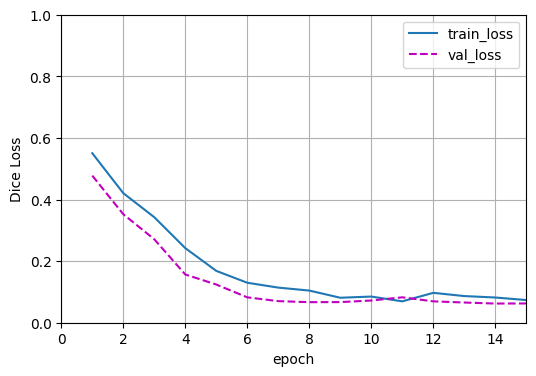

In [7]:
# 初始化 Animator
animator = Animator(
    xlabel='epoch',
    ylabel='Dice Loss',
    legend=['train_loss', 'val_loss'],
    xlim=[0, epochs],
    ylim=[0, 1.0],
    figsize=(6, 4)
)

print("\n开始训练...\n")

for epoch in range(epochs):
    # 训练阶段
    model.train()
    train_loss = 0
    train_loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
    
    for images, masks in train_loop:
        images = images.to(device)
        masks = masks.to(device)  # masks shape: [B, 1, H, W] or [B, H, W]?
        
        # 确保 masks 的维度正确
        if masks.dim() == 4 and masks.shape[1] == 1:
            masks = masks.squeeze(1)  # [B, H, W]
        
        outputs = model(images)
        loss = criterion(outputs, masks.long())  # 确保 target 是 long 类型
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())
    
    train_loss /= len(train_loader)
    
    # 验证阶段
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            if masks.dim() == 4 and masks.shape[1] == 1:
                masks = masks.squeeze(1)
            
            outputs = model(images)
            loss = criterion(outputs, masks.long())
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    
    # 更新动画
    animator.add(epoch + 1, [train_loss, val_loss])
    print(f"\n✓ Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print(f"\n训练完成！")

In [8]:
def visualize_predictions(model, dataloader, device='cuda', num_samples=4):
    """
    从数据加载器中获取一个批次并显示预测结果
    
    Args:
        model: 训练好的模型
        dataloader: 数据加载器
        device: 设备
        num_samples: 显示样本数量
    """
    model.eval()
    
    # 获取一个批次
    images, masks = next(iter(dataloader))
    images = images.to(device)
    masks = masks.to(device)
    
    # 预测
    with torch.no_grad():
        outputs = model(images)
        outputs = torch.softmax(outputs, dim=1)
        pred_masks = outputs[:, 1, :, :] > 0.5  # 取类别1，阈值0.5
    
    # 显示前 num_samples 个样本
    num_samples = min(num_samples, images.shape[0])
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    
    for i in range(num_samples):
        # 原图（反归一化）
        img = images[i].cpu().numpy().transpose(1, 2, 0)
        # 反归一化（ImageNet 统计值）
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        # 原始mask
        mask = masks[i].cpu().numpy().squeeze()
        
        # 预测mask
        pred_mask = pred_masks[i].cpu().numpy()
        
        # 显示
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'Original Image {i+1}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title(f'Ground Truth Mask {i+1}')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title(f'Predicted Mask {i+1}')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()


# 或者更简洁的版本
def show_batch_predictions(model, train_loader, val_loader, device='cuda'):
    """
    显示训练集和验证集的预测结果
    """
    # 从训练集取一个批次
    print("训练集预测结果:")
    visualize_predictions(model, train_loader, device)
    
    # 从验证集取一个批次
    print("\n验证集预测结果:")
    visualize_predictions(model, val_loader, device)

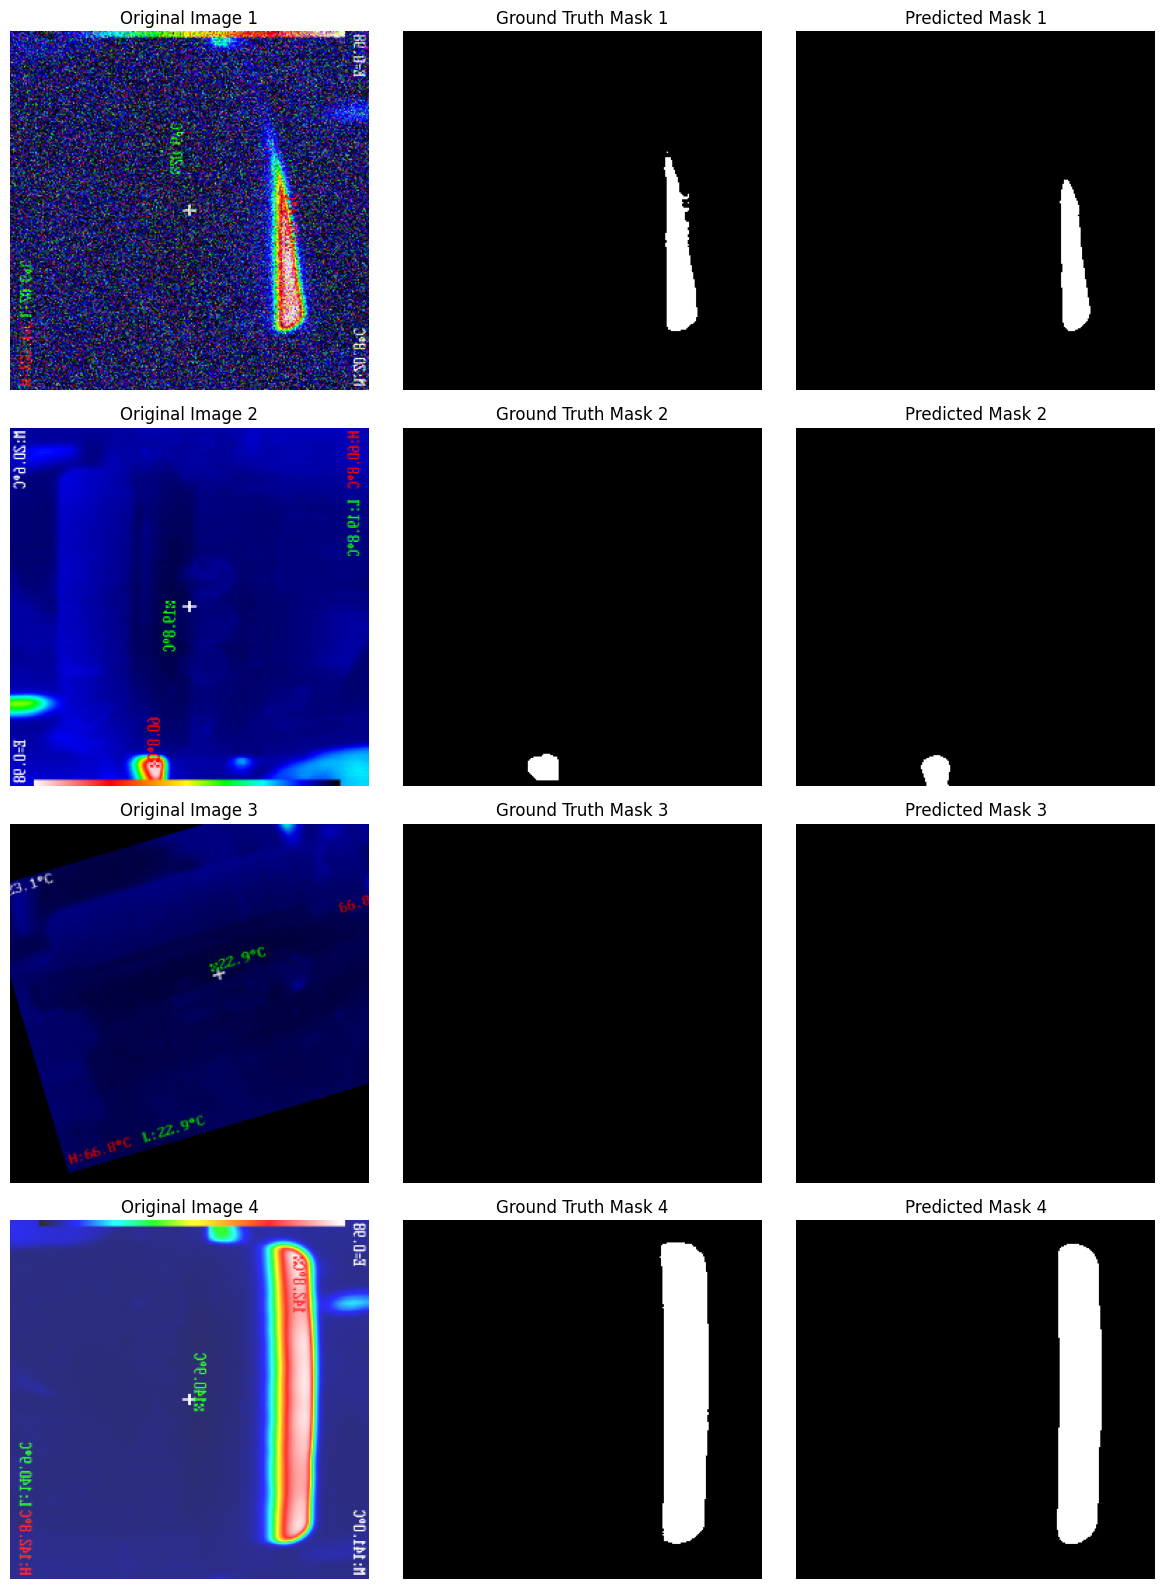

In [9]:
visualize_predictions(model, train_loader, device, num_samples=4)

In [10]:
torch.save(model.state_dict(), 'Res18Unet_fine_tuning.pth')